In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr,spearmanr
sns.set(style="darkgrid", color_codes=True, font_scale=1.33)

In [2]:
gnomad = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/resources/constraint/constraint_gnomad-v2.1.tsv',
                       usecols=['gene', 'lof_z', 'mis_z', 'syn_z', 'pLI'], index_col='gene')
# note: gnomad uses ENSG encoding, so there are duplicates -- this needs to be resolved
exac = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/resources/constraint/exac-final-cnv.gene.scores071316.txt',
                     sep='\s+', usecols=['gene_symbol', 'del.score', 'dup.score', 'cnv.score'], index_col='gene_symbol')

ukb_all = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_constraint_zscores_20181217.tsv',
                        header=None, names=['gene', 'ukb_z', 'ukb_pli'], index_col=0)

ukb_del = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_del_constraint-scores_20180322.tsv',
                        header=None, names=['gene', 'ukb_del_z'], index_col=0)

ukb_dup = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_dup_constraint-scores_20180322.tsv',
                        header=None, names=['gene', 'ukb_dup_z'], index_col=0)

df = reduce(lambda x,y: pd.merge(x, y, left_index=True, right_index=True), 
            [gnomad, exac, ukb_all, ukb_del, ukb_dup])
df.describe()

,lof_z,mis_z,syn_z,pLI,del.score,dup.score,cnv.score,ukb_z,ukb_pli,ukb_del_z,ukb_dup_z
count,63782.000000,64803.000000,64800.000000,6.378200e+04,64814.000000,64814.000000,64814.000000,64814.000000,64814.000000,64814.000000,64814.000000
mean,2.123648,0.888109,-0.066647,2.933505e-01,0.035978,0.007739,0.019881,0.051347,0.757669,0.042515,0.037591
std,1.877650,1.171518,1.153784,3.830880e-01,1.019647,1.020286,1.017259,0.113355,0.302375,0.112626,0.060546
min,-8.477200,-11.321000,-19.154000,7.896500e-156,-2.623544,-2.531252,-2.471628,-0.103808,-0.000000,-0.083101,-0.050013
25%,0.889072,0.179265,-0.580660,1.832300e-05,-0.354600,-0.467310,-0.491011,0.023786,0.706606,0.004539,0.025062
50%,1.810200,0.696410,0.058006,3.238700e-02,0.291099,0.261024,0.246939,0.038073,0.890143,0.017357,0.037670
75%,3.047350,1.447450,0.636945,6.140525e-01,0.703356,0.723650,0.741931,0.056733,0.955060,0.045483,0.042931
max,15.032000,11.370000,4.700700,1.000000e+00,3.813059,2.863585,3.021948,3.262034,1.000000,2.974261,0.580711


In [3]:
simp = df[~df.index.duplicated()]
simp.corr(method='spearman')**2

,lof_z,mis_z,syn_z,pLI,del.score,dup.score,cnv.score,ukb_z,ukb_pli,ukb_del_z,ukb_dup_z
lof_z,1.000000,0.493704,0.007609,0.404533,0.069329,0.015425,0.037307,0.000267,0.013222,0.073552,0.038321
mis_z,0.493704,1.000000,0.078668,0.324519,0.071203,0.027775,0.052944,0.001388,0.027423,0.023721,0.007201
syn_z,0.007609,0.078668,1.000000,0.000878,0.006322,0.012743,0.012125,0.000332,0.011916,0.001670,0.000646
pLI,0.404533,0.324519,0.000878,1.000000,0.071585,0.014200,0.045543,0.010695,0.018721,0.000096,0.000271
del.score,0.069329,0.071203,0.006322,0.071585,1.000000,0.107198,0.433181,0.003641,0.047346,0.021508,0.001432
dup.score,0.015425,0.027775,0.012743,0.014200,0.107198,1.000000,0.764196,0.010600,0.080067,0.004420,0.028088
cnv.score,0.037307,0.052944,0.012125,0.045543,0.433181,0.764196,1.000000,0.012312,0.110859,0.011561,0.024213
ukb_z,0.000267,0.001388,0.000332,0.010695,0.003641,0.010600,0.012312,1.000000,0.275108,0.518752,0.255616
ukb_pli,0.013222,0.027423,0.011916,0.018721,0.047346,0.080067,0.110859,0.275108,1.000000,0.164772,0.333603
ukb_del_z,0.073552,0.023721,0.001670,0.000096,0.021508,0.004420,0.011561,0.518752,0.164772,1.000000,0.006991


In [4]:
print('spearmanr={0:.3f}, p={1:.2e}'.format(*spearmanr(simp[['cnv.score', 'ukb_z']])))

spearmanr=0.111, p=3.03e-41


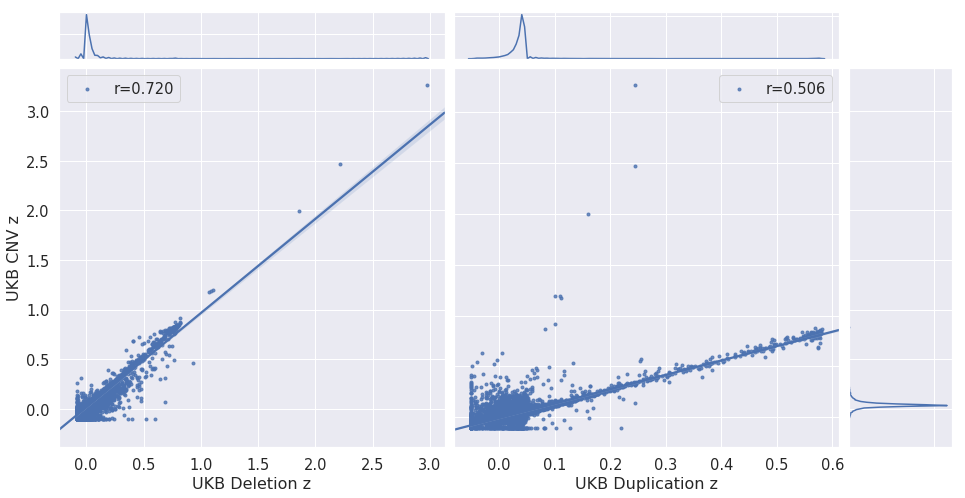

In [5]:
plt.clf()
fig = plt.figure(figsize=(16,8))
grid = plt.GridSpec(8,16)

# regression for UKB + DEL
ax0 = fig.add_subplot(grid[1:,:7])
sns.regplot(x='ukb_del_z', y='ukb_z', data=simp, ax=ax0, marker='.', 
            label='r={0:.3f}'.format(spearmanr(simp[['ukb_del_z', 'ukb_z']])[0]))
ax0.set_xlabel('UKB Deletion z'), ax0.set_ylabel('UKB CNV z')
ax0.legend(loc="best")

# regression for UKB + DUP 
ax1 = fig.add_subplot(grid[1:,7:14])
sns.regplot(x='ukb_dup_z', y='ukb_z', data=simp, ax=ax1, marker='.', 
            label='r={0:.3f}'.format(spearmanr(simp[['ukb_dup_z', 'ukb_z']])[0]))
ax1.set_xlabel('UKB Duplication z'), ax1.set_ylabel('')
ax1.set_yticklabels(['' for _ in ax1.get_yticklabels()])
ax1.legend(loc="best")

# kde for DEL z
ax = fig.add_subplot(grid[:1,:7])
sns.kdeplot(simp['ukb_del_z'].values, ax=ax)
ax.set_ylabel(''), ax.set_xlabel('')
ax.set_xticks(ax0.get_xticks())
ax.set_xlim(ax0.get_xlim())
ax.set_xticklabels(['' for _ in ax.get_xticklabels()])
ax.set_yticklabels(['' for _ in ax.get_yticklabels()])

# KDE for DUP z
ax = fig.add_subplot(grid[:1,7:14])
sns.kdeplot(simp['ukb_dup_z'].values, ax=ax)
ax.set_ylabel(''), ax.set_xlabel('')
ax.set_xticks(ax1.get_xticks())
ax.set_xlim(ax1.get_xlim())
ax.set_xticklabels(['' for _ in ax.get_xticklabels()])
ax.set_yticklabels(['' for _ in ax.get_yticklabels()])

# KDE for UKB
ax = fig.add_subplot(grid[1:,14:])
sns.kdeplot(filter(lambda x: x < 1, simp['ukb_z'].tolist()), ax=ax, vertical=True)
ax.set_ylabel(''), ax.set_xlabel('')
ax.set_yticks(ax0.get_yticks())
ax.set_ylim(ax0.get_ylim())
ax.set_yticklabels(['' for _ in ax.get_yticklabels()])
ax.set_xticklabels(['' for _ in ax.get_xticklabels()])

plt.show()

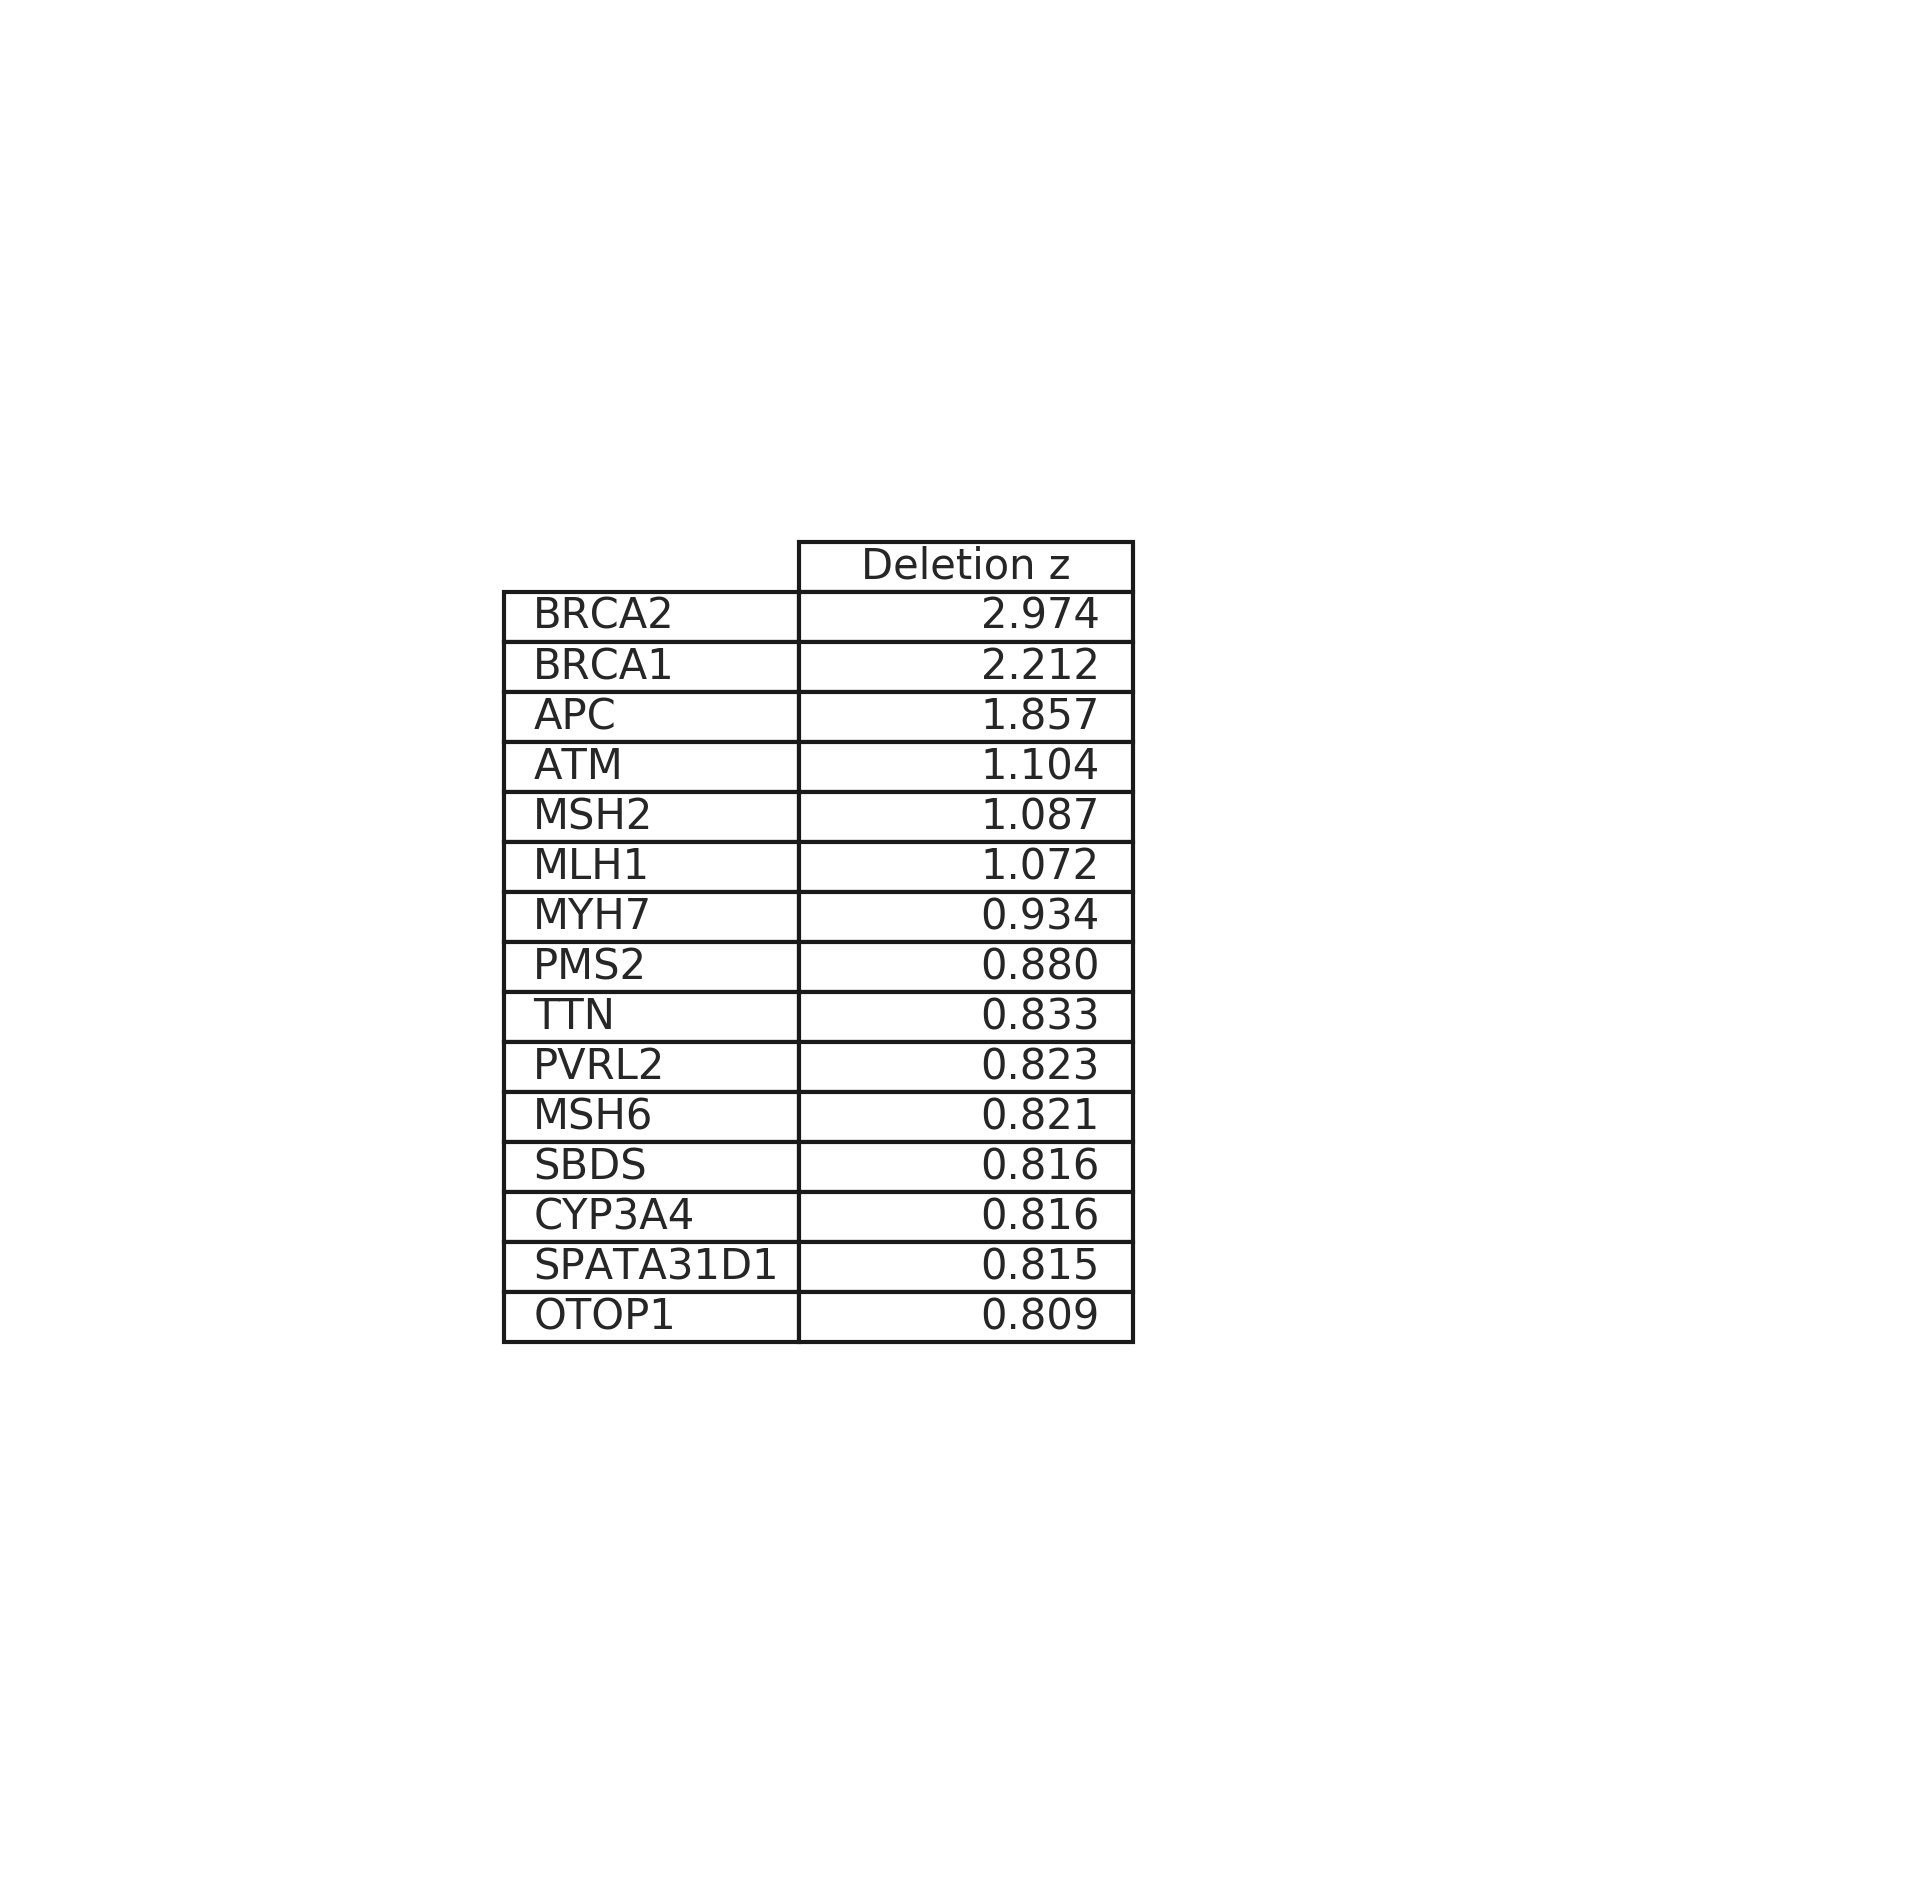

In [6]:
top = ukb_del[['ukb_del_z']].sort_values('ukb_del_z').tail(15)[::-1]
plt.figure(figsize=(8,8), dpi=300)
tab = plt.table(cellText=map(lambda x:['{:.3f}'.format(x[0])], 
                             top.values.tolist()),
                rowLabels=top.index,
                colLabels=['Deletion z'],
                colWidths = [0.18, 0.18],
                loc='center'
               )
tab.auto_set_font_size(False)
tab.set_fontsize(10)
plt.axis('tight')
plt.axis('off')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

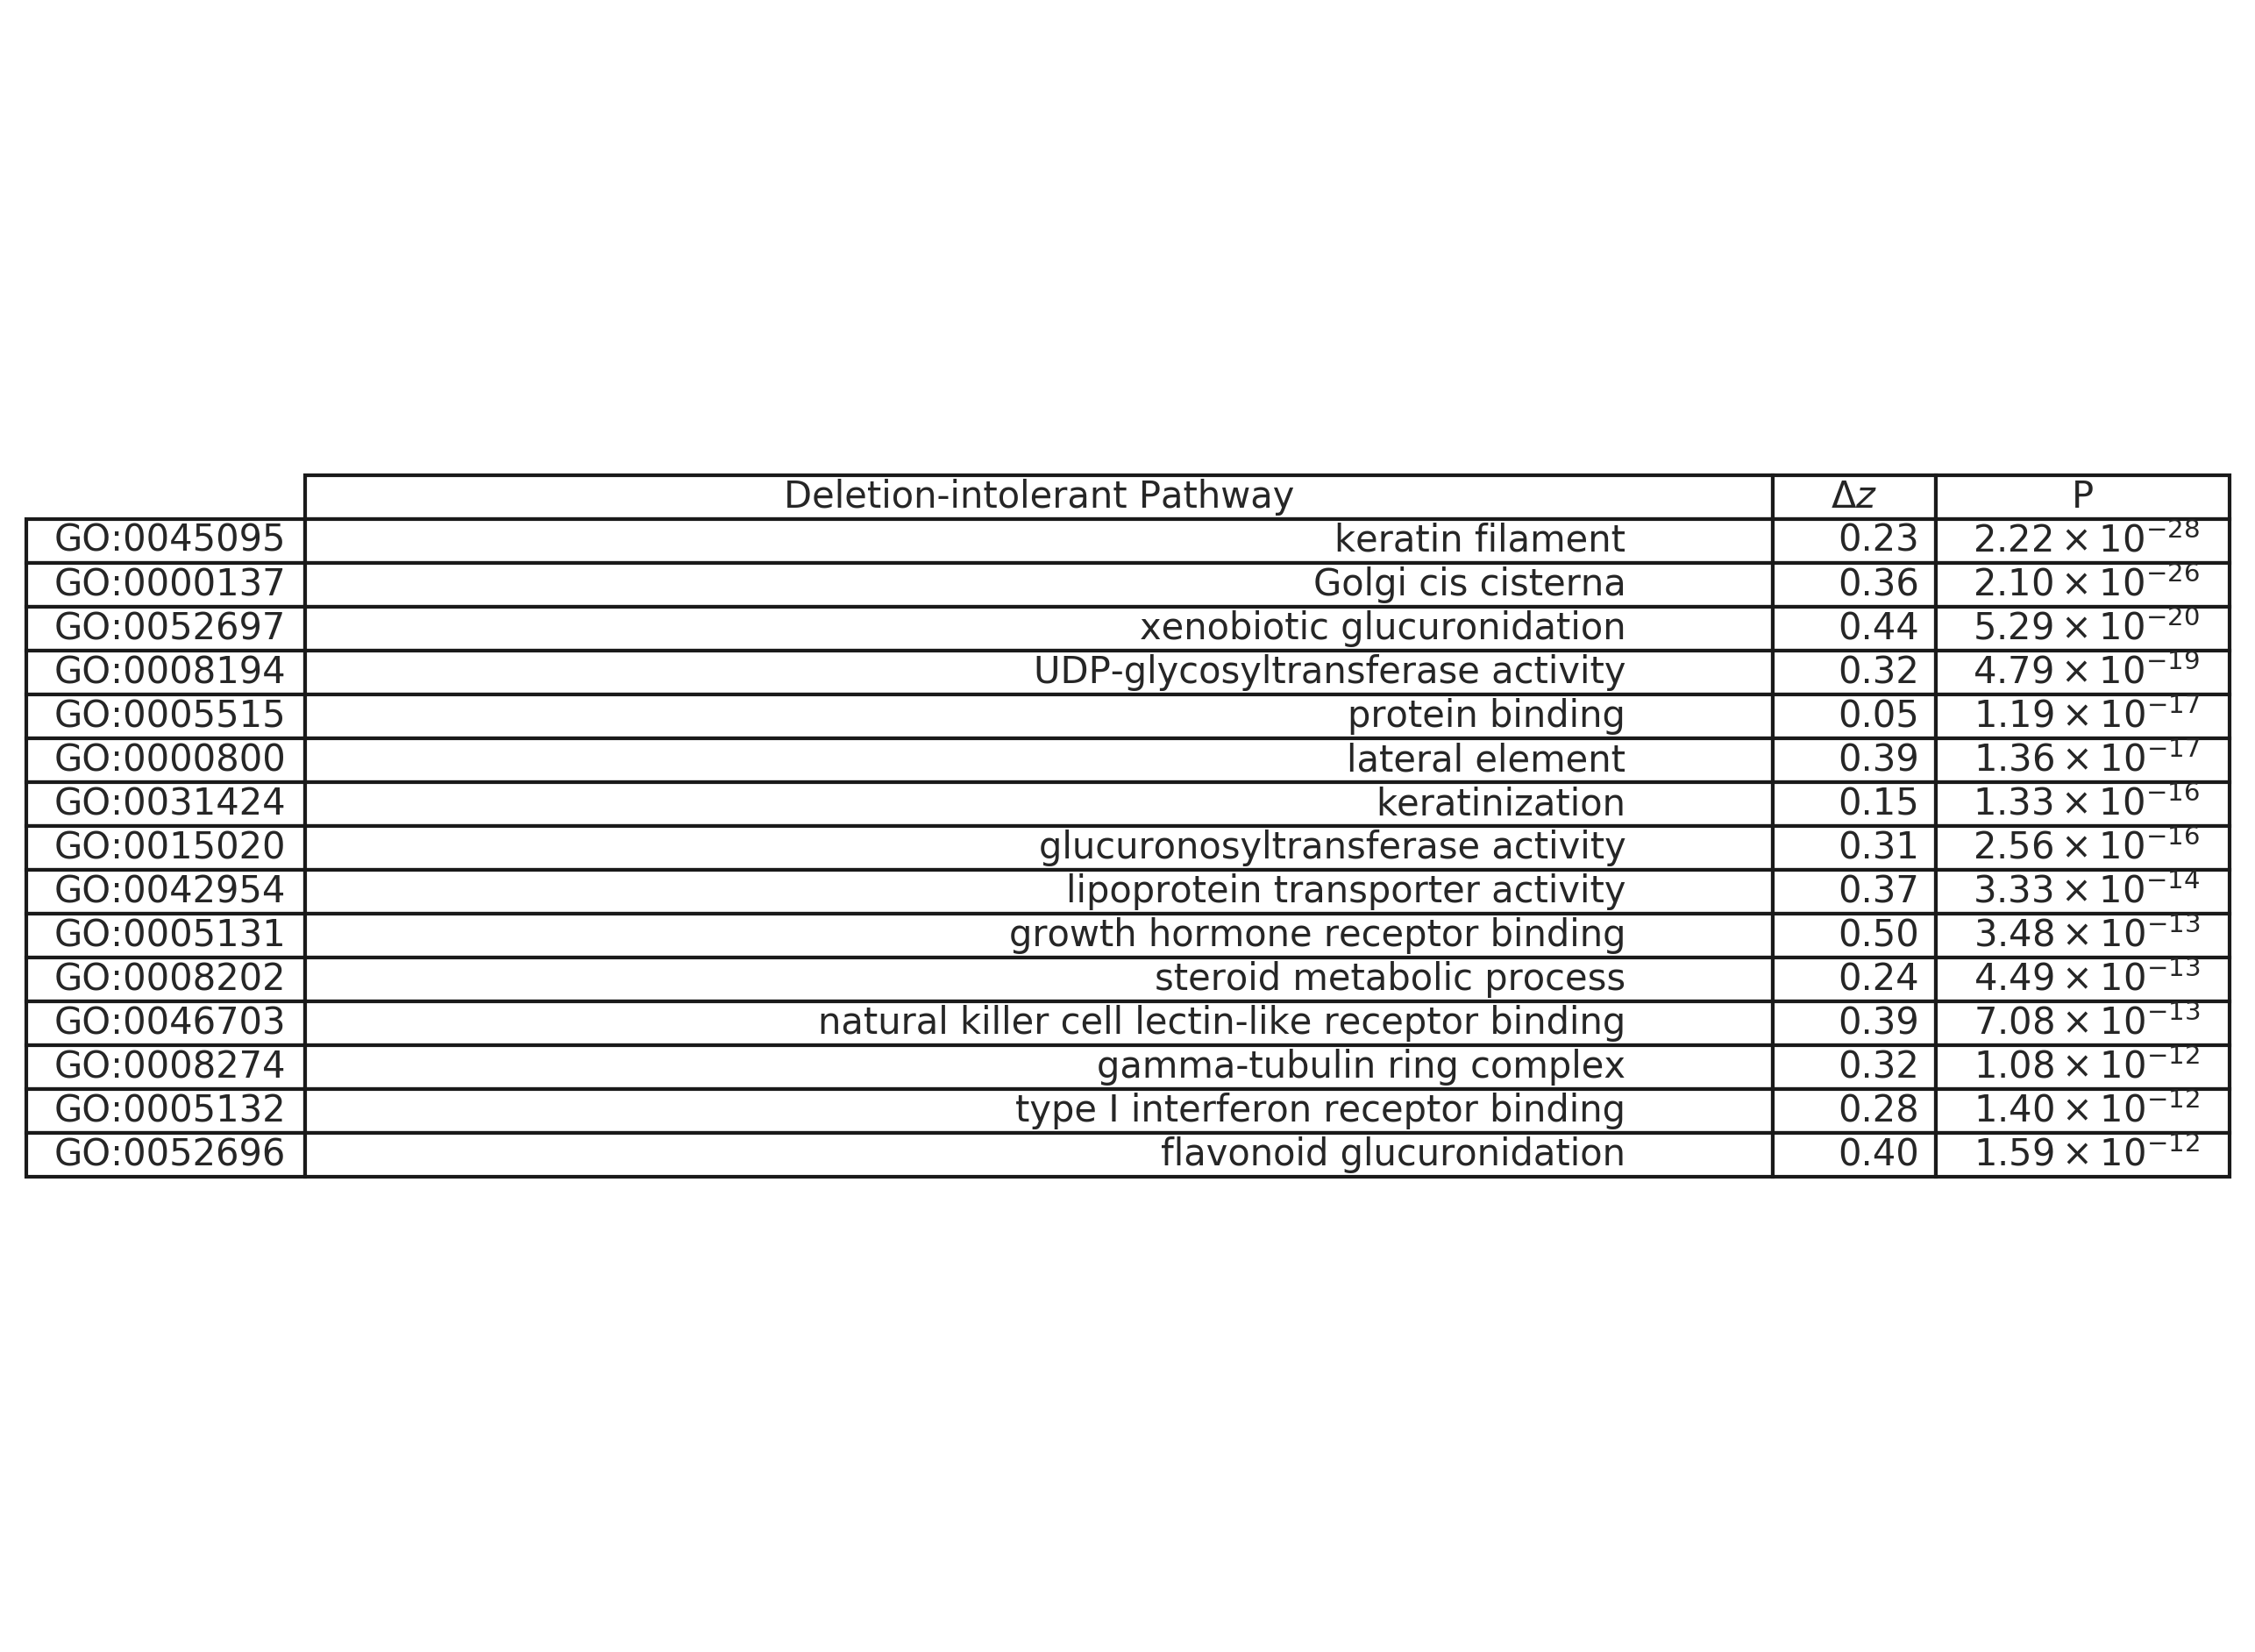

In [18]:
path = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_del_pathway-enrichment_20180322.tsv',
                     header=None, names=['ID', 'BETA', 'P', 'NAME', 'N'], index_col='ID')
top = path.query('N > 9').sort_values('P')[['NAME', 'BETA', 'P']].head(15)
plt.figure(figsize=(8,8), dpi=300)
tab = plt.table(cellText=map(lambda x:[x[0], '{:.2f}'.format(x[1]), 
                                 '${0:.2f} \\times 10^{{{1}}}$'.format(x[2]*(10**int(1-np.log10(x[2]))), 
                                                                      int(np.log10(x[2]))-1)], 
                             top.values.tolist()),
                rowLabels=top.index,
                colLabels=['Deletion-intolerant Pathway', '$\Delta z$', 'P'],
                colWidths = [0.9, 0.1, 0.18],
                loc='center',
               )
tab.auto_set_font_size(False)
tab.set_fontsize(10)
# tab.scale(8,8)
plt.axis('tight')
plt.axis('off')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

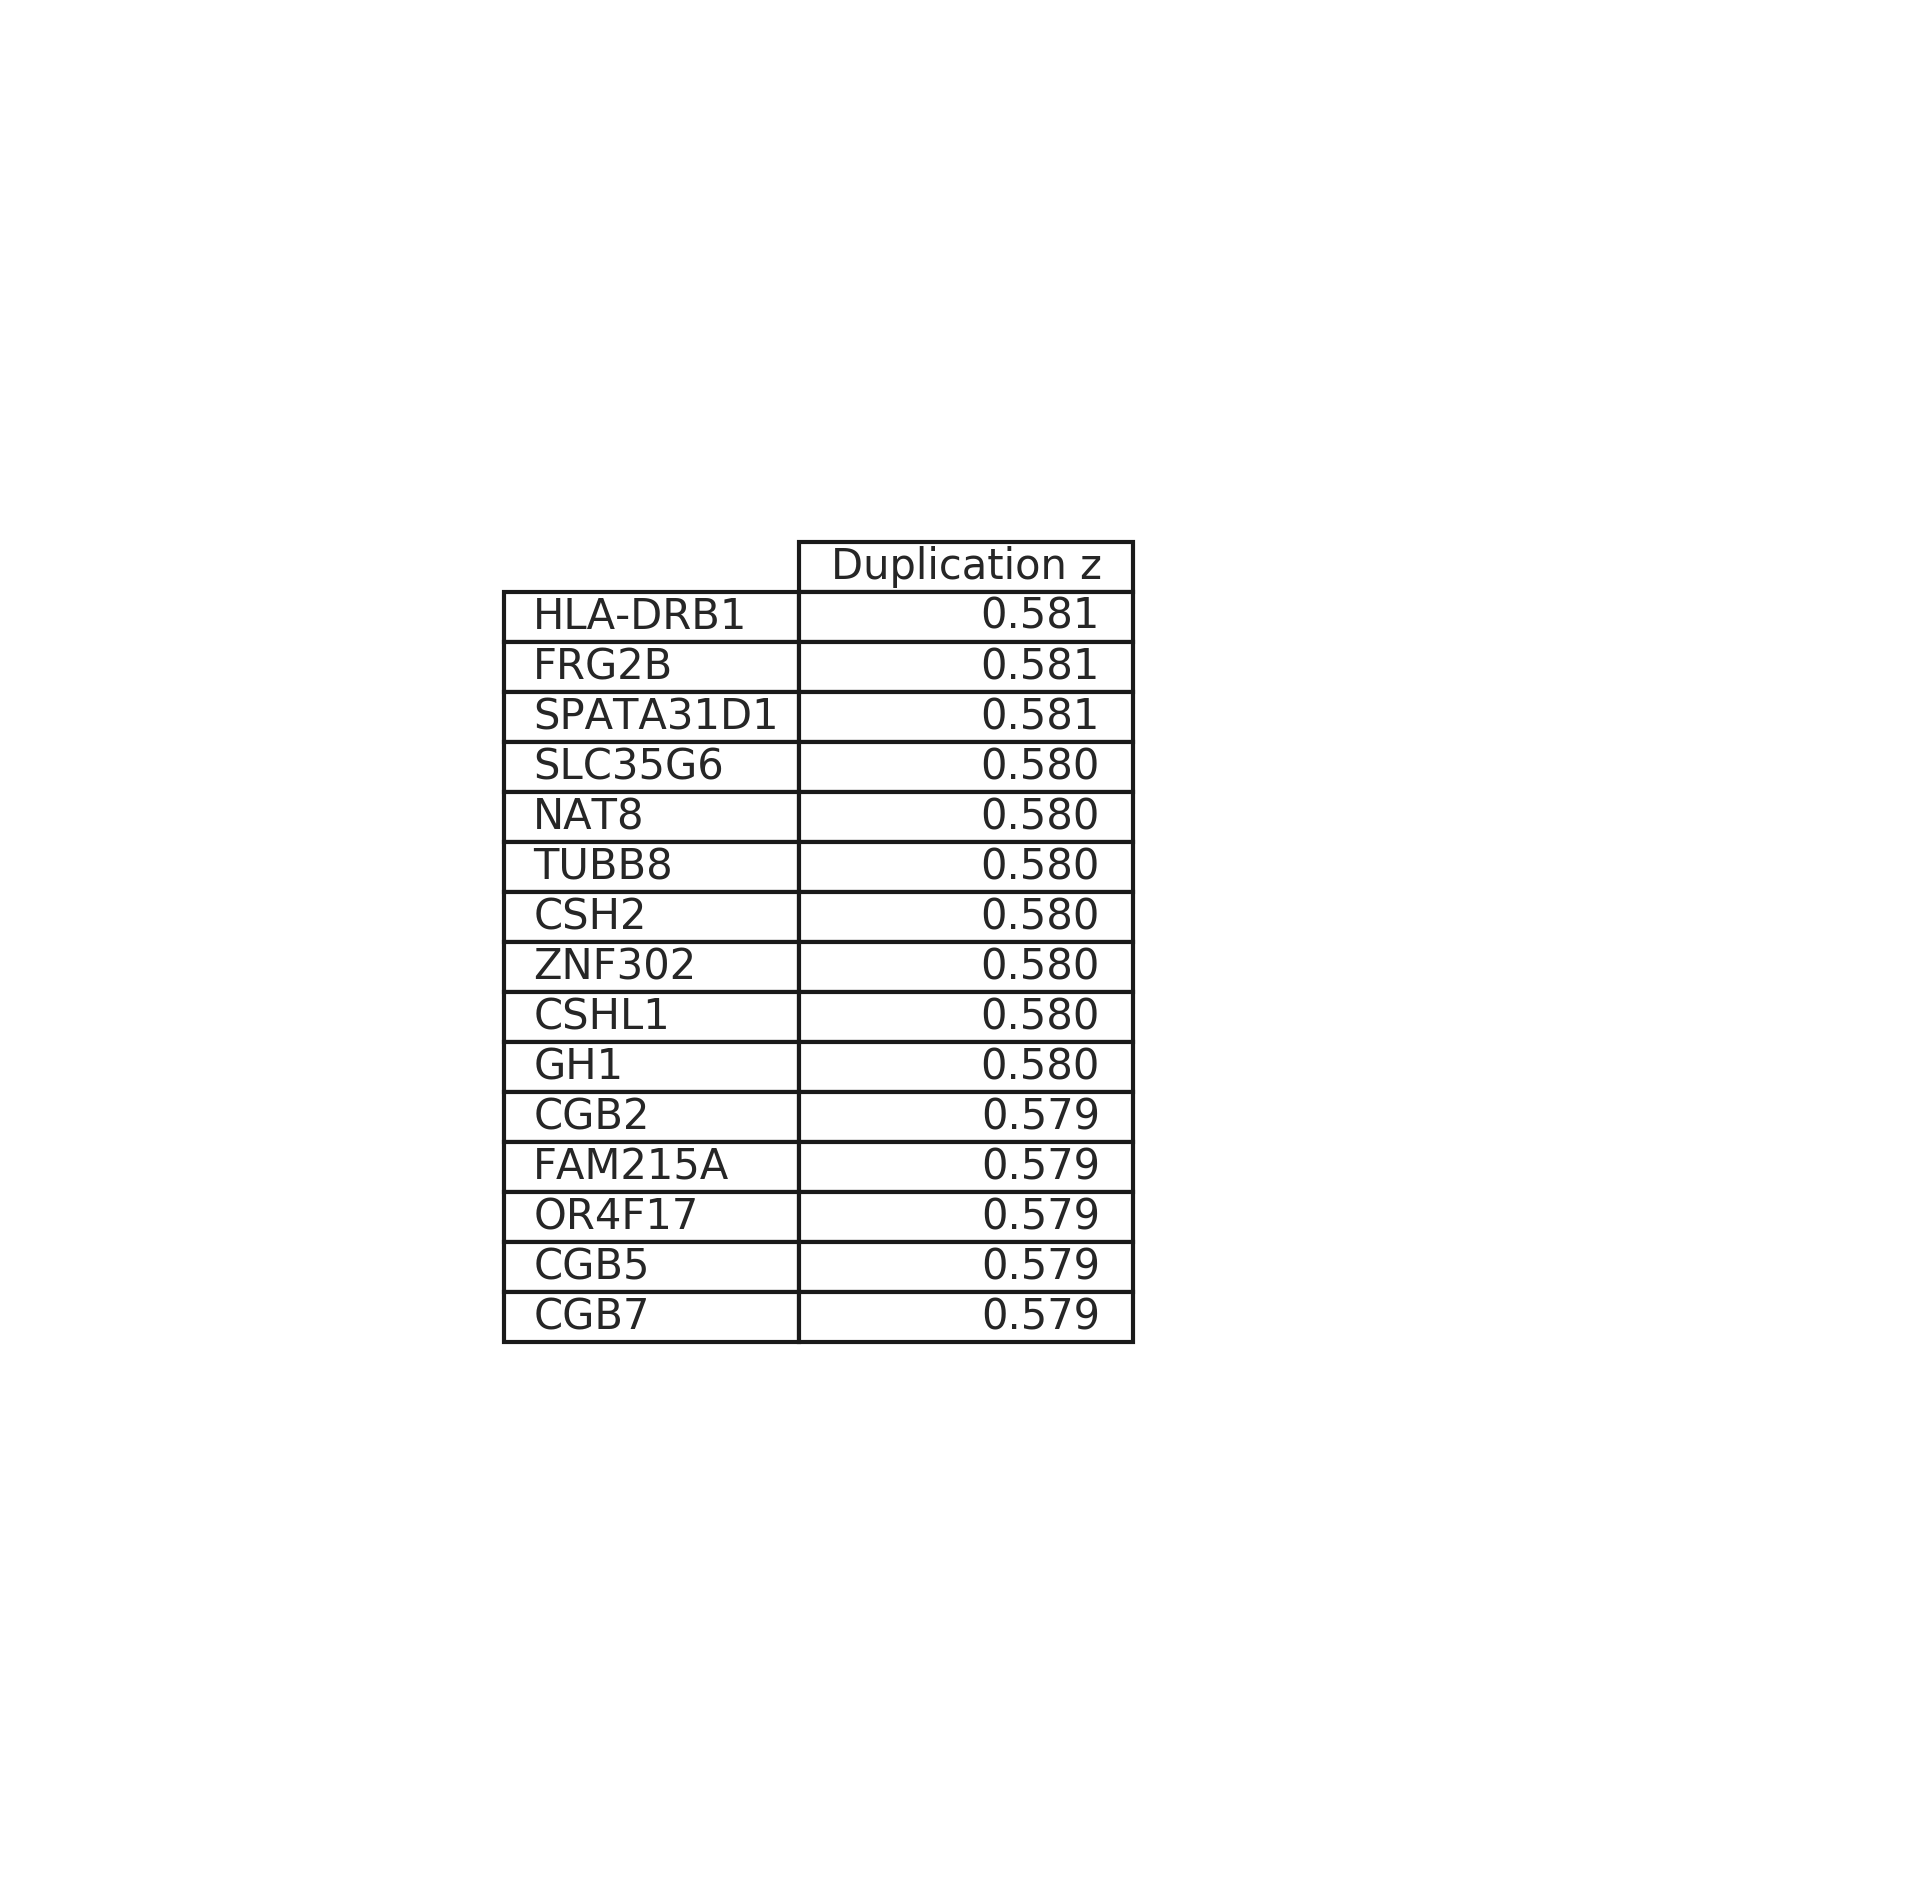

In [11]:
top = ukb_dup[['ukb_dup_z']].sort_values('ukb_dup_z').tail(15)[::-1]
plt.figure(figsize=(8,8), dpi=300)
tab = plt.table(cellText=map(lambda x:['{:.3f}'.format(x[0])], 
                             top.values.tolist()),
                rowLabels=top.index,
                colLabels=['Duplication z'],
                colWidths = [0.18, 0.18],
                loc='center'
               )
tab.auto_set_font_size(False)
tab.set_fontsize(10)
plt.axis('tight')
plt.axis('off')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

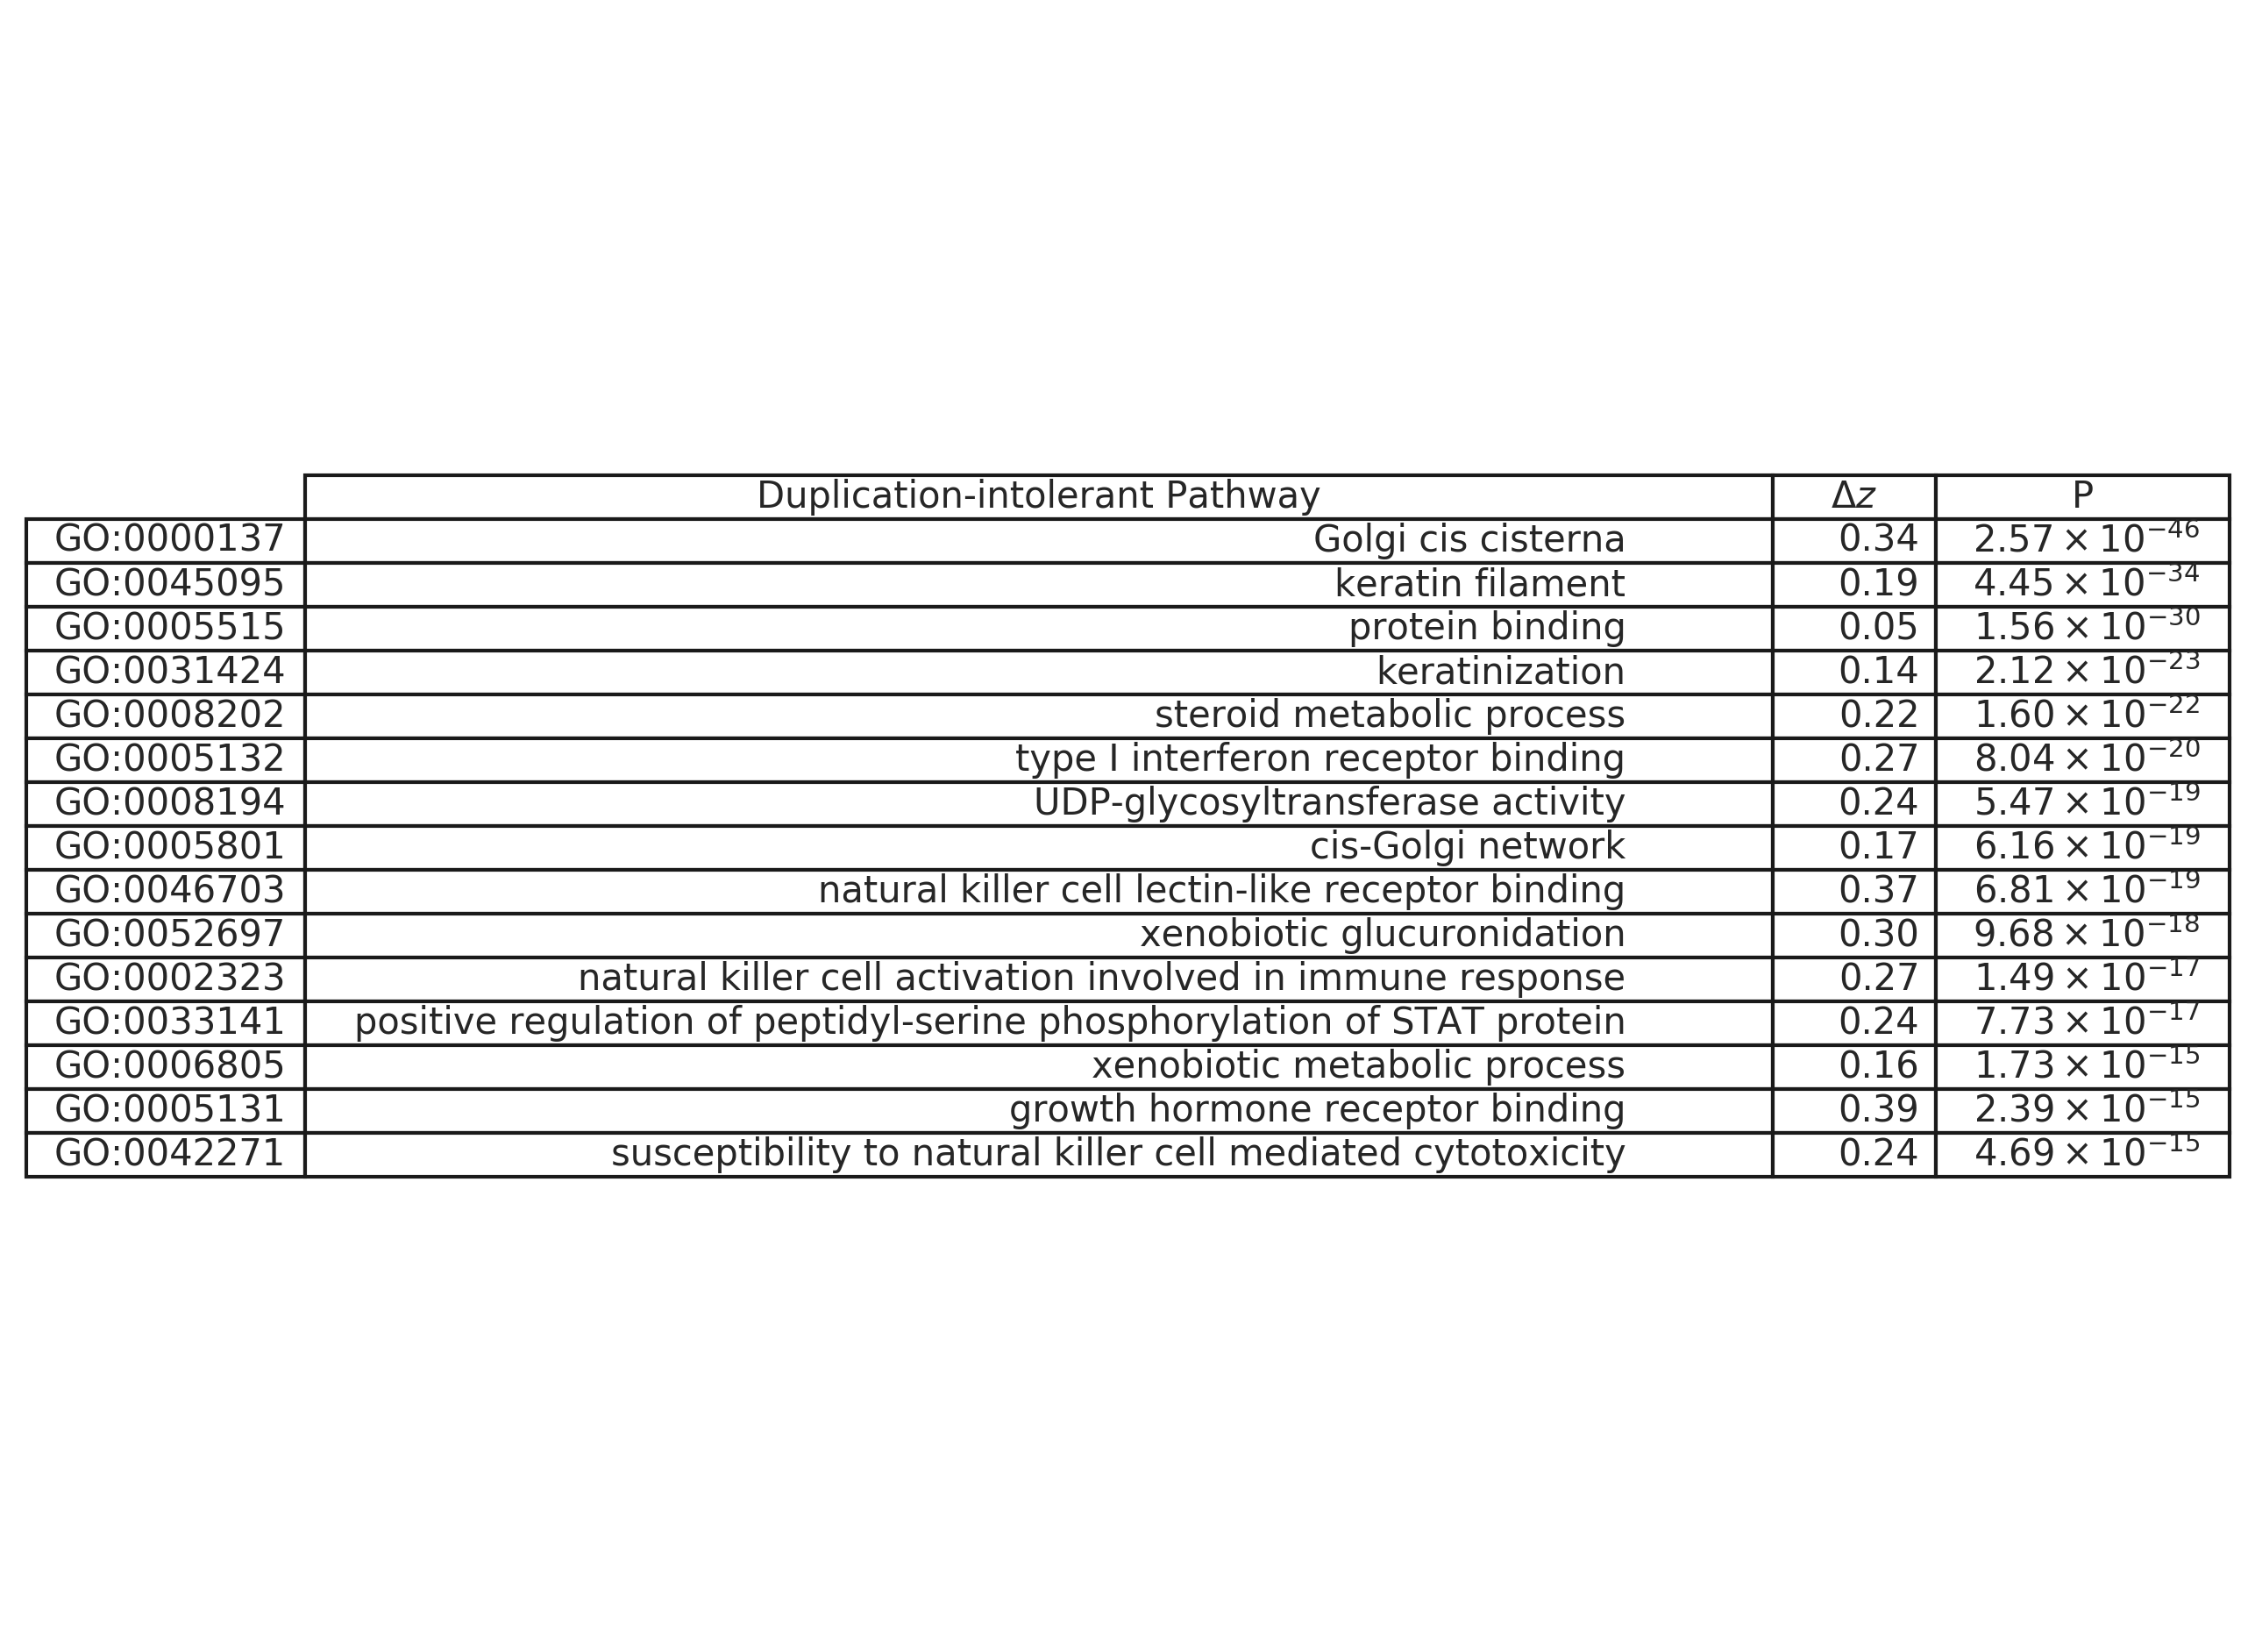

In [17]:
path = pd.read_table('/oak/stanford/groups/jpriest/cnv_ukb/cnv_dup_pathway-enrichment_20180322.tsv',
                     header=None, names=['ID', 'BETA', 'P', 'NAME', 'N'], index_col='ID')
top = path.query('N > 9').sort_values('P')[['NAME', 'BETA', 'P']].head(15)
plt.figure(figsize=(8,8), dpi=300)
tab = plt.table(cellText=map(lambda x:[x[0], '{:.2f}'.format(x[1]), 
                                 '${0:.2f} \\times 10^{{{1}}}$'.format(x[2]*(10**int(1-np.log10(x[2]))), 
                                                                      int(np.log10(x[2]))-1)], 
                             top.values.tolist()),
                rowLabels=top.index,
                colLabels=['Duplication-intolerant Pathway', '$\Delta z$', 'P'],
                colWidths = [0.9, 0.1, 0.18],
                loc='center'
               )
tab.auto_set_font_size(False)
tab.set_fontsize(10)
# tab.scale(8,8)
plt.axis('tight')
plt.axis('off')
plt.xticks([],[])
plt.yticks([],[])
plt.show()